# The Dengue Exercise - Lane A (you prompt, the agent builds)

**SISMID 2026 - Day 1, 11:00.** Drive a coding agent (Codex, Claude Code, or Antigravity
CLI). Paste each prompt, run the code it writes, and apply the check. Each prompt matches
a step on the slides and produces roughly the matching **Lane B** cell. Not set up? Use Lane B.

Data: `../data/MX_Dengue_trends.csv` (Mexico, monthly, 2004-2011).


## Step 1: visualize

> *Load `MX_Dengue_trends.csv`. `Dengue CDC` is monthly dengue cases in Mexico; `dengue`*
> *is Google search interest. Plot cases over time, overlay the `dengue` search series on a*
> *second y-axis, and print the correlation between the two columns.*

**Check:** do they move together? any lead/lag, gaps, or spikes?


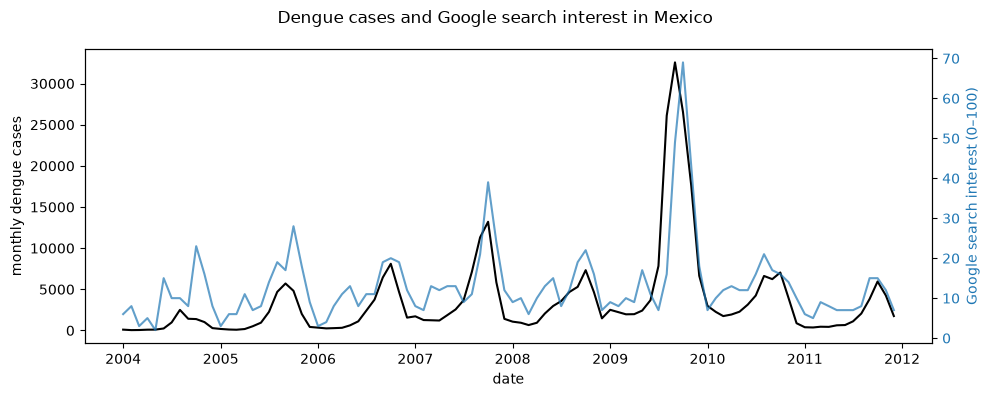

Pearson correlation (Dengue CDC vs dengue): 0.808


In [1]:
# Agent's Step 1 code:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_path = Path('../data/MX_Dengue_trends.csv')
if not data_path.exists():
    data_path = Path('day1-1100-dengue-exercise/data/MX_Dengue_trends.csv')

df = pd.read_csv(data_path, parse_dates=['Date'])

fig, cases_axis = plt.subplots(figsize=(10, 4))
cases_axis.plot(df['Date'], df['Dengue CDC'], color='black', label='dengue cases (CDC)')
cases_axis.set_xlabel('date')
cases_axis.set_ylabel('monthly dengue cases', color='black')
cases_axis.tick_params(axis='y', labelcolor='black')

search_axis = cases_axis.twinx()
search_axis.plot(df['Date'], df['dengue'], color='tab:blue', alpha=0.7, label='dengue search interest')
search_axis.set_ylabel('Google search interest (0–100)', color='tab:blue')
search_axis.tick_params(axis='y', labelcolor='tab:blue')

fig.suptitle('Dengue cases and Google search interest in Mexico')
fig.tight_layout()
plt.show()

correlation = df['Dengue CDC'].corr(df['dengue'])
print(f'Pearson correlation (Dengue CDC vs dengue): {correlation:.3f}')


## Step 2: least squares

> *Using only the first 36 months (2004-2006) as training, fit ordinary least squares:*
> *`Dengue CDC ~ dengue`. Report the intercept, slope, and in-sample R^2, and overlay the*
> *fitted line on a scatter of cases vs search.*


intercept: -1023.90
slope: 242.62 cases per search-interest point
in-sample R²: 0.518


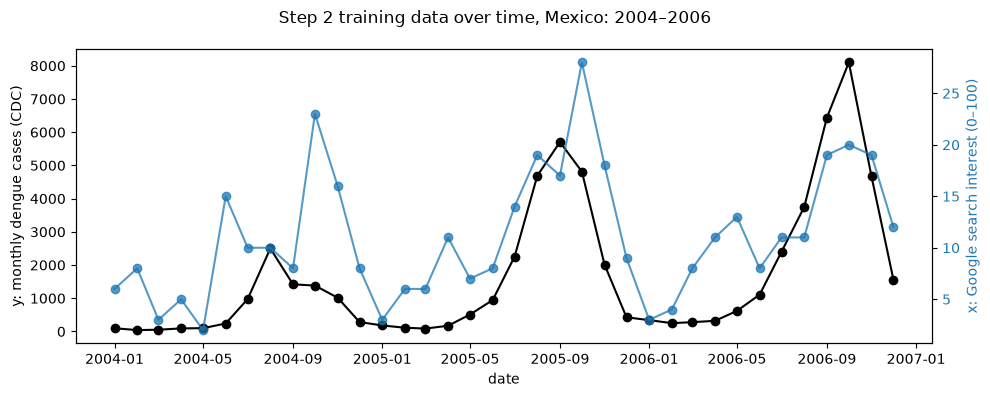

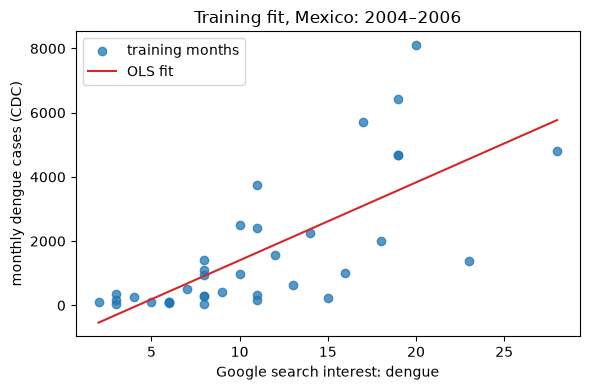

In [7]:
# Agent's Step 2 code:
from sklearn.linear_model import LinearRegression

train = df.iloc[:36].copy()  # January 2004 through December 2006
X_train = train[['dengue']]
y_train = train['Dengue CDC']

model = LinearRegression().fit(X_train, y_train)
train['fitted_cases'] = model.predict(X_train)

print(f'intercept: {model.intercept_:.2f}')
print(f'slope: {model.coef_[0]:.2f} cases per search-interest point')
print(f'in-sample R²: {model.score(X_train, y_train):.3f}')

# Evidence for the fitted relationship: inspect both variables in time order.
fig, cases_axis = plt.subplots(figsize=(10, 4))
cases_axis.plot(train['Date'], y_train, color='black', marker='o', label='y: dengue cases (CDC)')
cases_axis.set_xlabel('date')
cases_axis.set_ylabel('y: monthly dengue cases (CDC)', color='black')
cases_axis.tick_params(axis='y', labelcolor='black')

search_axis = cases_axis.twinx()
search_axis.plot(train['Date'], X_train['dengue'], color='tab:blue', marker='o', alpha=0.75, label='x: dengue search interest')
search_axis.set_ylabel('x: Google search interest (0–100)', color='tab:blue')
search_axis.tick_params(axis='y', labelcolor='tab:blue')

fig.suptitle('Step 2 training data over time, Mexico: 2004–2006')
fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(train['dengue'], y_train, alpha=0.75, label='training months')
plot_order = train.sort_values('dengue')
plt.plot(plot_order['dengue'], plot_order['fitted_cases'], color='tab:red', label='OLS fit')
plt.xlabel('Google search interest: dengue')
plt.ylabel('monthly dengue cases (CDC)')
plt.title('Training fit, Mexico: 2004–2006')
plt.legend()
plt.tight_layout()
plt.show()


## Step 3: predict + validate

> *Using the intercept and slope from training, predict dengue cases for 2007-2011 from the*
> *`dengue` search column alone. Plot predicted vs actual over time, and report the*
> *out-of-sample correlation and RMSE. Do NOT refit on 2007+.*

**Check:** the last training point is 2006; nothing after 2006 should touch the fit.


out-of-sample correlation: 0.826
out-of-sample RMSE: 4968.4 cases


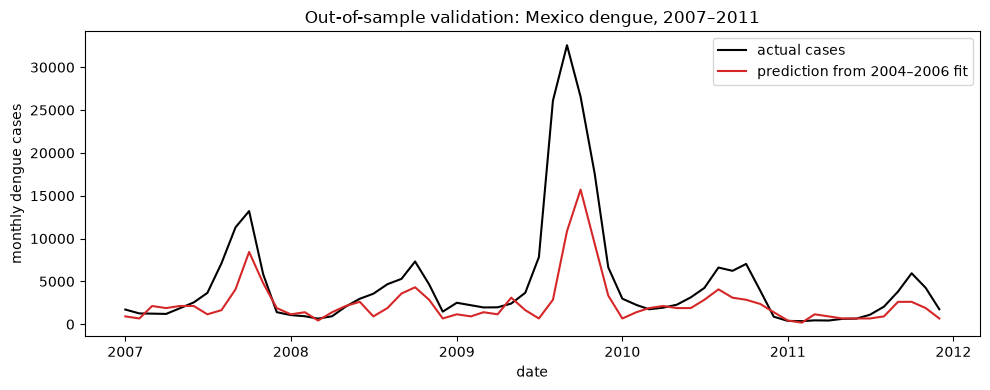

In [3]:
# Agent's Step 3 code:
import numpy as np

validation = df.iloc[36:].copy()  # January 2007 through December 2011
# model was fit above on the first 36 months only; do not call fit here.
validation['predicted_cases'] = model.predict(validation[['dengue']])

out_of_sample_correlation = validation['Dengue CDC'].corr(validation['predicted_cases'])
rmse = np.sqrt(np.mean((validation['Dengue CDC'] - validation['predicted_cases']) ** 2))
print(f'out-of-sample correlation: {out_of_sample_correlation:.3f}')
print(f'out-of-sample RMSE: {rmse:.1f} cases')

plt.figure(figsize=(10, 4))
plt.plot(validation['Date'], validation['Dengue CDC'], color='black', label='actual cases')
plt.plot(validation['Date'], validation['predicted_cases'], color='tab:blue', label='prediction from 2004–2006 fit')
negative_predictions = validation['predicted_cases'] < 0
plt.scatter(
    validation.loc[negative_predictions, 'Date'],
    validation.loc[negative_predictions, 'predicted_cases'],
    color='red', marker='o', zorder=3, label='prediction below 0',
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('date')
plt.ylabel('monthly dengue cases')
plt.title('Out-of-sample validation: Mexico dengue, 2007–2011')
plt.legend()
plt.tight_layout()
plt.show()


## Reflection

- You described steps and checks; the agent wrote the pandas/sklearn.
- The one-term line is the honest baseline; **ARGO** (Day 2) adds selected terms and dynamic training.
- **Further stretch:** rolling-window (dynamic) training + Lasso on the Zika-tutorial data.


Training rows: 30; held-out rows: 19
Selected terms: sintomas, el zika, sintomas del zika, virus zika, virus, zika colombia, el zika sintomas, zika embarazo, zika microcefalia, zika fiebre, sika, el sica, zika repite
in-sample R²: 0.984
out-of-sample R²: -1.205
out-of-sample RMSE: 1251.2 cases


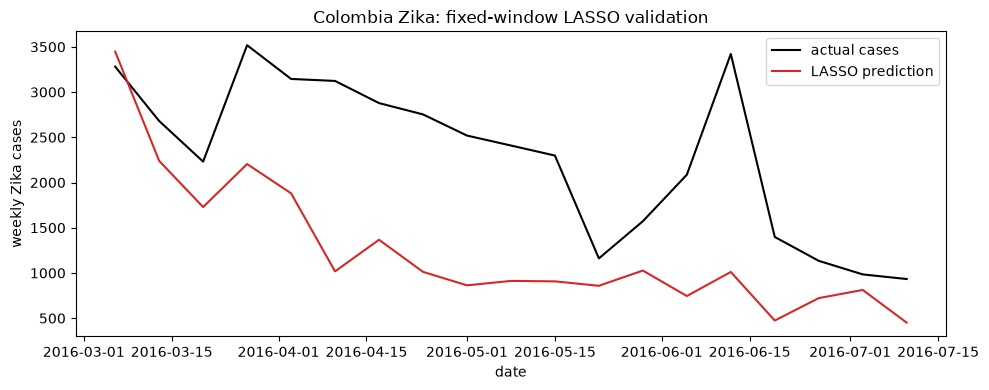

In [5]:
# Fixed training-window LASSO validation for the Colombia Zika data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

zika_url = 'https://raw.githubusercontent.com/sarahhbellum/Zika-tutorial/master/Zika_Colombia_cleaned.csv'
zika_df = pd.read_csv(zika_url)
zika_df.columns = zika_df.columns.str.strip()
zika_df['date'] = pd.to_datetime(zika_df['date'], format='%m/%d/%y')
query_terms = zika_df.columns.drop(['date', 'cases', 'twitter', 'healthmap'])

train = zika_df.iloc[:30].copy()
test = zika_df.iloc[30:].copy()  # 19 rows: the source CSV has 49, not 50, rows.
print(f'Training rows: {len(train)}; held-out rows: {len(test)}')

# Scaling happens inside the pipeline; the LASSO and its time-ordered CV see training data only.
zika_model = Pipeline([
    ('scale', StandardScaler()),
    ('lasso', LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=42, max_iter=100_000)),
])
zika_model.fit(train[query_terms], train['cases'])

train_prediction = zika_model.predict(train[query_terms])
test['predicted_cases'] = zika_model.predict(test[query_terms])  # no refit on held-out rows

lasso_coefficients = zika_model.named_steps['lasso'].coef_
selected_terms = query_terms[lasso_coefficients != 0]
print('Selected terms:', ', '.join(selected_terms) if len(selected_terms) else 'none')
print(f'in-sample R²: {r2_score(train["cases"], train_prediction):.3f}')
print(f'out-of-sample R²: {r2_score(test["cases"], test["predicted_cases"]):.3f}')
rmse = np.sqrt(np.mean((test['cases'] - test['predicted_cases']) ** 2))
print(f'out-of-sample RMSE: {rmse:.1f} cases')

plt.figure(figsize=(10, 4))
plt.plot(test['date'], test['cases'], color='black', label='actual cases')
plt.plot(test['date'], test['predicted_cases'], color='tab:red', label='LASSO prediction')
plt.title('Colombia Zika: fixed-window LASSO validation')
plt.xlabel('date')
plt.ylabel('weekly Zika cases')
plt.legend()
plt.tight_layout()
plt.show()
